# 04 - GMM Density Modelling & BIC-Based Component Selection

In [17]:
import os
import sys
from pathlib import Path

_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.mixture import GaussianMixture

from config import SEED, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR

## 1 - Load training split

In [ ]:
data = np.load(PROCESSED_DIR / "splits.npz")
X_train, y_train = data["X_train"], data["y_train"]

X0 = X_train[y_train == 0]  # benign
X1 = X_train[y_train == 1]  # melanoma

print(f"Training set  : {len(X_train)} samples, {X_train.shape[1]} features")
print(f"  Benign      : {len(X0)}")
print(f"  Melanoma    : {len(X1)}")

Training set  : 1335 samples, 96 features
  Benign      : 668
  Melanoma    : 667


In [ ]:
K_RANGE = list(range(1, 7)) 
CLASS_DATA = {0: ("Benign",   X0),
              1: ("Melanoma", X1)}


def fit_gmm_bic(X, k_range, seed, verbose=True):
    """
    Fit full-covariance GMMs for K in k_range.

    Returns (bic_scores, chosen_k, best_model, cov_type).
    For each K the EM convergence status is printed when verbose=True.
    """
    cov_type   = "full"
    bic_scores = []
    models     = []

    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            random_state=seed,
        )
        gmm.fit(X)
        bic = gmm.bic(X)

        if verbose:
            conv_str = "\u2713 converged" if gmm.converged_ else "\u2717 NOT converged"
            print(f"    K={k}  BIC={bic:12.2f}  {conv_str} (n_iter={gmm.n_iter_})")

        bic_scores.append(bic)
        models.append(gmm)

    best_idx = int(np.argmin(bic_scores))
    best_gmm = models[best_idx]
    return bic_scores, k_range[best_idx], best_gmm, cov_type


results = {}
for label, (name, X_cls) in CLASS_DATA.items():
    print(f"\n== {name} ==")
    bic_scores, k_best, best_gmm, cov_type = fit_gmm_bic(X_cls, K_RANGE, SEED)
    results[label] = dict(
        name=name, bic_scores=bic_scores, k_best=k_best,
        best_gmm=best_gmm, cov_type=cov_type,
        converged=bool(best_gmm.converged_), n_iter=int(best_gmm.n_iter_),
    )
    print(f"  \u2192 Selected K={k_best}, BIC={min(bic_scores):.2f}, "
          f"cov='{cov_type}', converged={best_gmm.converged_}, "
          f"n_iter={best_gmm.n_iter_}")



== Benign ==
    K=1  BIC=  -504284.63  ✓ converged (n_iter=2)
    K=2  BIC=  -522716.49  ✓ converged (n_iter=7)
    K=3  BIC=  -498491.93  ✓ converged (n_iter=35)
    K=4  BIC=  -477774.40  ✓ converged (n_iter=18)
    K=5  BIC=  -452600.23  ✓ converged (n_iter=19)
    K=6  BIC=  -425187.33  ✓ converged (n_iter=13)
  → Selected K=2, BIC=-522716.49, cov='full', converged=True, n_iter=7

== Melanoma ==
    K=1  BIC=  -539273.13  ✓ converged (n_iter=2)
    K=2  BIC=  -526799.88  ✓ converged (n_iter=12)
    K=3  BIC=  -501877.98  ✓ converged (n_iter=9)
    K=4  BIC=  -486930.22  ✓ converged (n_iter=23)
    K=5  BIC=  -460534.68  ✓ converged (n_iter=21)
    K=6  BIC=  -434103.89  ✓ converged (n_iter=12)
  → Selected K=1, BIC=-539273.13, cov='full', converged=True, n_iter=2


## 3 - BIC curves

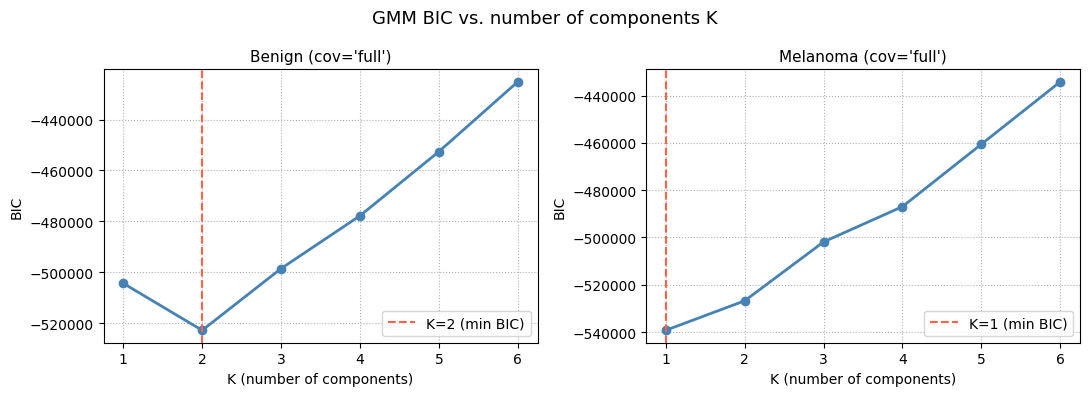

Figure saved to: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\figures\bic_curves.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
fig.suptitle("GMM BIC vs. number of components K", fontsize=13)

for ax, (label, res) in zip(axes, results.items()):
    ax.plot(K_RANGE, res["bic_scores"], marker="o", linewidth=2, color="steelblue")
    ax.axvline(res["k_best"], color="tomato", linestyle="--",
               label=f"K={res['k_best']} (min BIC)")
    ax.set_title(f"{res['name']} (cov='{res['cov_type']}')", fontsize=11)
    ax.set_xlabel("K (number of components)")
    ax.set_ylabel("BIC")
    ax.set_xticks(K_RANGE)
    ax.legend()
    ax.grid(True, linestyle=":")

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "bic_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'bic_curves.png'}")

## 4 - Save fitted GMMs

In [21]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

gmm_paths = {0: PROCESSED_DIR / "gmm_benign.pkl",
             1: PROCESSED_DIR / "gmm_melanoma.pkl"}

for label, res in results.items():
    joblib.dump(res["best_gmm"], gmm_paths[label])
    print(f"Saved {res['name']} GMM (K={res['k_best']}) → {gmm_paths[label]}")

Saved Benign GMM (K=2) → C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\data\processed\gmm_benign.pkl
Saved Melanoma GMM (K=1) → C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\data\processed\gmm_melanoma.pkl


## 5 - Summary 

In [22]:
rows = [
    {
        "class":           res["name"],
        "K_chosen":        res["k_best"],
        "BIC_value":       round(min(res["bic_scores"]), 4),
        "covariance_type": res["cov_type"],
        "converged":       res["converged"],
        "n_iter":          res["n_iter"],
    }
    for res in results.values()
]

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

TABLES_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(TABLES_DIR / "gmm_selection.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'gmm_selection.csv'}")

   class  K_chosen    BIC_value covariance_type  converged  n_iter
  Benign         2 -522716.4931            full       True       7
Melanoma         1 -539273.1314            full       True       2

Saved to: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables\gmm_selection.csv


## 6 - BIC seed stability

Re-running BIC selection over several random seeds to verify that the chosen K is not  
a local minimum.

In [25]:
STABILITY_SEEDS = [42, 7, 123, 99, 314]

stab_rows = []
for seed in STABILITY_SEEDS:
    for label, (name, X_cls) in CLASS_DATA.items():
        bics, k_best, _, cov_type = fit_gmm_bic(X_cls, K_RANGE, seed, verbose=False)
        stab_rows.append({
            "seed":    seed,
            "class":   name,
            "K_best":  k_best,
            "BIC_min": round(min(bics), 2),
            "cov_type": cov_type,
        })

stab_df = pd.DataFrame(stab_rows)

# Pivot for compact display: rows = seeds, cols = class
pivot = stab_df.pivot(index="seed", columns="class", values="K_best")
print("K_best per seed and class:")
print(pivot.to_string())

# Report stability
for cls in ["Benign", "Melanoma"]:
    vals = stab_df.loc[stab_df["class"] == cls, "K_best"]
    mode = int(vals.mode().iloc[0])
    print(f"\n{cls}: K_best values = {sorted(vals.tolist())}  "
          f"- mode={mode}, unique={sorted(vals.unique().tolist())}")

TABLES_DIR.mkdir(parents=True, exist_ok=True)
stab_df.to_csv(TABLES_DIR / "gmm_seed_stability.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'gmm_seed_stability.csv'}")

K_best per seed and class:
class  Benign  Melanoma
seed                   
7           2         1
42          2         1
99          2         1
123         2         1
314         2         1

Benign: K_best values = [2, 2, 2, 2, 2]  - mode=2, unique=[2]

Melanoma: K_best values = [1, 1, 1, 1, 1]  - mode=1, unique=[1]

Saved to: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables\gmm_seed_stability.csv
